In [29]:
import nltk

nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Alienware\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [30]:
import sys
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_news_data

news_df = load_news_data()

Loading from: C:\Users\Alienware\Desktop\kaim works\news-sentiment-analysis\data\raw\newsData\raw_analyst_ratings.csv


In [31]:
from src.data_loader import load_stock_data

stock_df = load_stock_data("AAPL.csv")

In [32]:
news_df["date"] = pd.to_datetime(news_df["date"], errors="coerce", utc=True).dt.tz_localize(None)

stock_df["Date"] = pd.to_datetime(stock_df["Date"], errors="coerce")

In [33]:
news_df["trading_date"] = news_df["date"].dt.date

stock_df["trading_date"] = stock_df["Date"].dt.date

In [35]:
news_df["weekday"] = news_df["date"].dt.weekday

from pandas.tseries.offsets import BDay

news_df["aligned_date"] = news_df["date"]

weekend_mask = news_df["date"].dt.weekday >= 5

news_df.loc[weekend_mask, "aligned_date"] = (
    news_df.loc[weekend_mask, "date"] + BDay(1)
)

news_df["aligned_date"] = pd.to_datetime(news_df["aligned_date"]).dt.date

In [36]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

news_df["sentiment_score"] = news_df["headline"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

In [37]:
daily_sentiment = (
    news_df.groupby(["aligned_date", "stock"])["sentiment_score"]
    .mean()
    .reset_index()
)

In [38]:
stock_df["daily_return"] = (
    stock_df["Close"].pct_change() * 100
)

In [39]:
merged_df = pd.merge(
    daily_sentiment,
    stock_df,
    left_on="aligned_date",
    right_on="trading_date",
    how="inner"
)

In [40]:
correlation = merged_df["sentiment_score"].corr(
    merged_df["daily_return"]
)

print("Correlation:", correlation)

Correlation: 0.15438473702625988


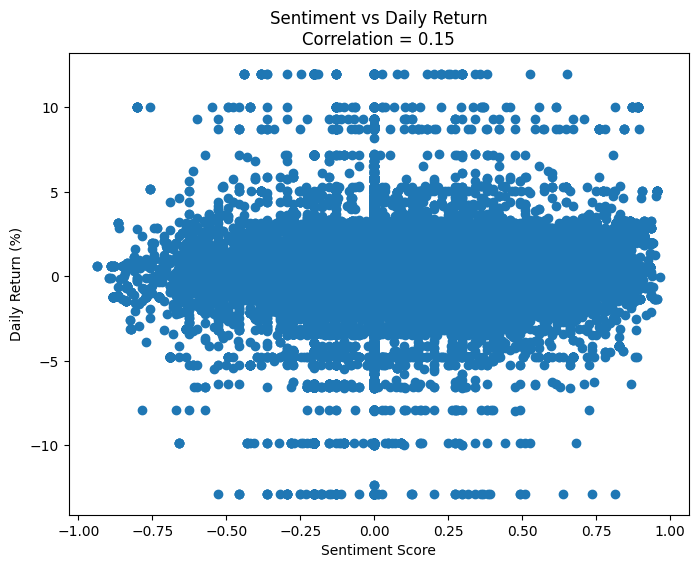

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    merged_df["sentiment_score"],
    merged_df["daily_return"]
)

plt.title(f"Sentiment vs Daily Return\nCorrelation = {correlation:.2f}")

plt.xlabel("Sentiment Score")
plt.ylabel("Daily Return (%)")

plt.show()

In [42]:
def classify_sentiment(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"
    
merged_df["sentiment_category"] = merged_df[
    "sentiment_score"
].apply(classify_sentiment)

In [43]:
category_returns = (
    merged_df.groupby("sentiment_category")["daily_return"]
    .mean()
)

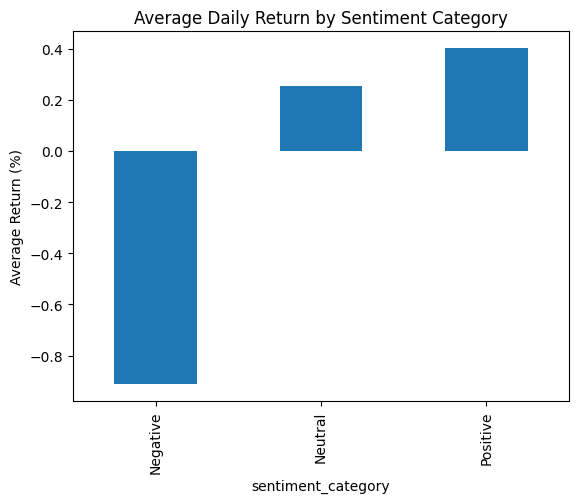

In [44]:
category_returns.plot(kind="bar")

plt.title("Average Daily Return by Sentiment Category")
plt.ylabel("Average Return (%)")

plt.show()

In [45]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

news_df["sentiment_score"] = news_df["headline"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)